# 07 - Outlier Analysis

## Dataset: Telco Customer Churn

An outlier is an observation that is unusually far from the other observations in a dataset.

Outliers can provide useful information, but they can also indicate data-quality problems.

In this notebook, we will investigate:

- What is an Outlier?
- Why Outliers Occur
- Types of Outliers
- Univariate Outliers
- Multivariate Outliers

Detection techniques:

- IQR Method
- Z-Score Method
- Box Plot
- Scatter Plot

For detected outliers, we will investigate whether they are:

- Genuine observations
- Data-entry errors
- Unusual but valid observations

We will also decide whether an outlier should be:

- Removed
- Transformed
- Retained

Outliers will not be automatically removed.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. What is an Outlier?

An outlier is an observation that is significantly different from the majority of observations.

For example, if most customers have monthly charges between 20 and 100, a customer with an extremely high charge may be considered a potential outlier.

Outliers should be investigated rather than automatically removed.

## 2. Why Outliers Occur

Outliers can occur for several reasons:

1. Data-entry errors
2. Measurement errors
3. System or technical errors
4. Genuine unusual observations
5. Natural variation in the data

An outlier is not necessarily an error.

Therefore, each detected outlier should be investigated before deciding what to do with it.

## 3. Types of Outliers

### Univariate Outlier

An observation that is unusual based on a single variable.

Example:

A customer has an unusually high MonthlyCharges value.

### Multivariate Outlier

An observation that may not be unusual for individual variables but is unusual when multiple variables are considered together.

Example:

A customer may have a normal tenure and normal MonthlyCharges individually, but the combination of these values may be unusual.

In [3]:
numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numerical_columns].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## 5. Univariate Outliers - IQR Method

The Interquartile Range (IQR) method identifies potential outliers using the first and third quartiles.

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Values below the lower bound or above the upper bound are considered potential outliers.

In [4]:
# Function to detect outliers using IQR

def detect_iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound

In [5]:
# Detect IQR outliers for MonthlyCharges

outliers_monthly, lower, upper = detect_iqr_outliers(
    df,
    "MonthlyCharges"
)

print("Lower Bound:", lower)
print("Upper Bound:", upper)
print("Number of Outliers:", len(outliers_monthly))

Lower Bound: -46.02499999999999
Upper Bound: 171.375
Number of Outliers: 0


In [6]:
# Display potential outliers

outliers_monthly[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
].head(20)

,customerID,tenure,MonthlyCharges,TotalCharges


In [7]:
# Count IQR outliers for each numerical variable

iqr_results = []

for column in numerical_columns:
    data = df[column].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (data < lower_bound) |
        (data > upper_bound)
    ).sum()

    iqr_results.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    })

iqr_results = pd.DataFrame(iqr_results)

iqr_results

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,SeniorCitizen,0.00,0.0000,0.0000,0.00000,0.00000,1142
1,tenure,9.00,55.0000,46.0000,-60.00000,124.00000,0
2,MonthlyCharges,35.50,89.8500,54.3500,-46.02500,171.37500,0
3,TotalCharges,401.45,3794.7375,3393.2875,-4688.48125,8884.66875,0


## 7. Box Plot

A box plot is a useful visualization for identifying potential outliers.

Points appearing beyond the whiskers may represent potential outliers.

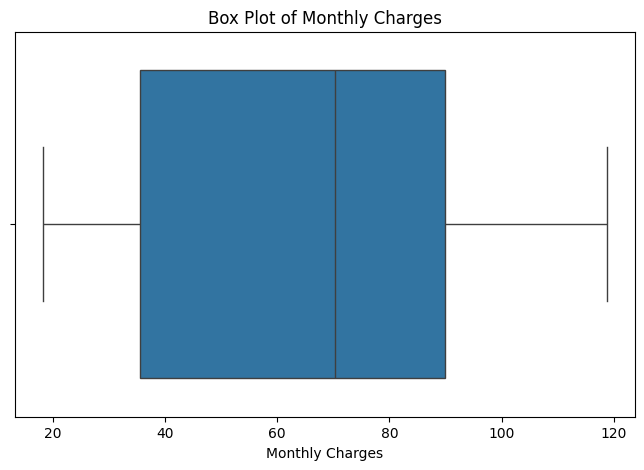

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["MonthlyCharges"])

plt.title("Box Plot of Monthly Charges")
plt.xlabel("Monthly Charges")

plt.show()

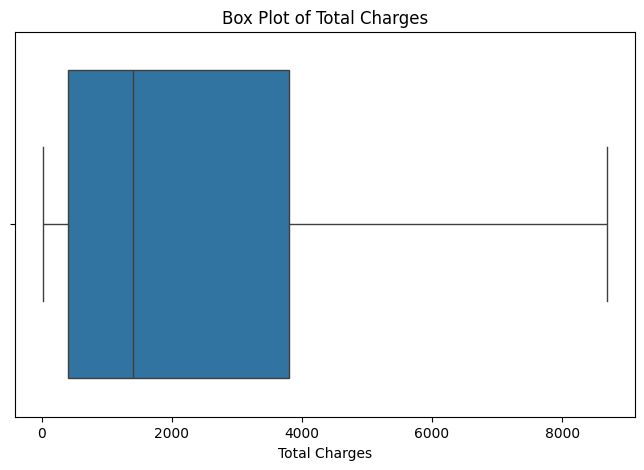

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["TotalCharges"])

plt.title("Box Plot of Total Charges")
plt.xlabel("Total Charges")

plt.show()

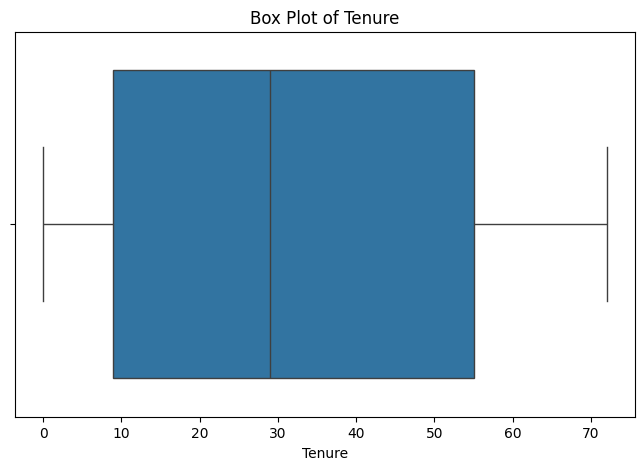

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["tenure"])

plt.title("Box Plot of Tenure")
plt.xlabel("Tenure")

plt.show()

## 8. Z-Score Method

A Z-score tells us how many standard deviations an observation is away from the mean.

A commonly used rule is:

- Z-score > +3 → potential outlier
- Z-score < -3 → potential outlier

The threshold should be treated as a screening rule, not an automatic decision.

In [11]:
# Calculate Z-scores for MonthlyCharges

mean = df["MonthlyCharges"].mean()
std = df["MonthlyCharges"].std()

df["MonthlyCharges_ZScore"] = (
    (df["MonthlyCharges"] - mean) / std
)

df[["MonthlyCharges", "MonthlyCharges_ZScore"]].head()

,MonthlyCharges,MonthlyCharges_ZScore
0,29.85,-1.160241
1,56.95,-0.259611
2,53.85,-0.362635
3,42.30,-0.746482
4,70.70,0.197351


In [12]:
# Identify potential Z-score outliers

zscore_outliers = df[
    df["MonthlyCharges_ZScore"].abs() > 3
]

print("Number of Z-score outliers:", len(zscore_outliers))

zscore_outliers[
    ["customerID", "MonthlyCharges", "MonthlyCharges_ZScore"]
]

Number of Z-score outliers: 0


,customerID,MonthlyCharges,MonthlyCharges_ZScore


In [13]:
# Detect Z-score outliers for all numerical variables

zscore_results = []

for column in numerical_columns:
    data = df[column].dropna()

    z_scores = (data - data.mean()) / data.std()

    outlier_count = (z_scores.abs() > 3).sum()

    zscore_results.append({
        "Column": column,
        "Outlier Count": outlier_count
    })

zscore_results = pd.DataFrame(zscore_results)

zscore_results

,Column,Outlier Count
0,SeniorCitizen,0
1,tenure,0
2,MonthlyCharges,0
3,TotalCharges,0


## 10. Scatter Plot

A scatter plot can help identify unusual observations involving two numerical variables.

For example, we can examine:

- Tenure vs MonthlyCharges
- Tenure vs TotalCharges
- MonthlyCharges vs TotalCharges

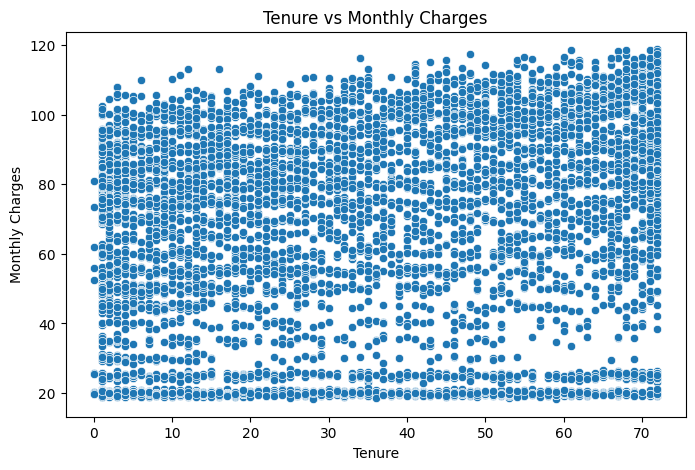

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges"
)

plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")

plt.show()

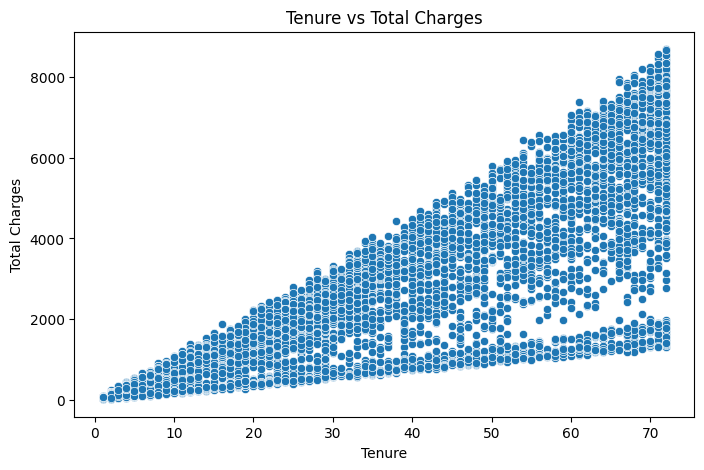

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="tenure",
    y="TotalCharges"
)

plt.title("Tenure vs Total Charges")
plt.xlabel("Tenure")
plt.ylabel("Total Charges")

plt.show()

## 11. Multivariate Outliers

Multivariate outliers are unusual observations considering multiple variables simultaneously.

For this dataset, we can visually investigate multiple numerical features using scatter plots and pair plots.

A point may appear normal when looking at one variable but unusual when considering its relationship with another variable.

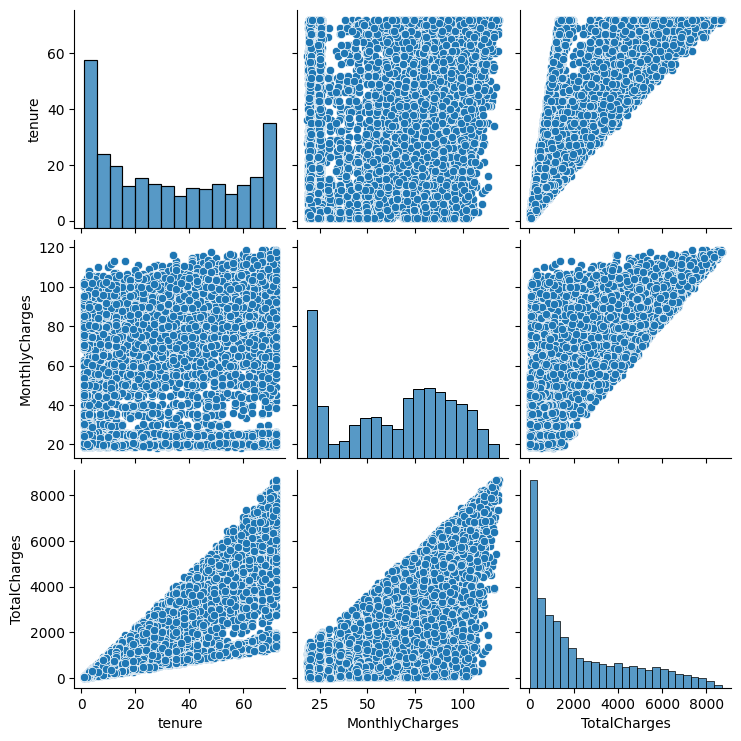

In [16]:
sns.pairplot(
    df[
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ].dropna()
)

plt.show()

## 12. Investigating Detected Outliers

After detecting an outlier, we should ask:

1. Is it a genuine observation?
2. Is it a data-entry error?
3. Is it unusual but valid?
4. Should it be removed?
5. Should it be transformed?
6. Should it be retained?

We should not automatically remove every outlier.

In [17]:
# Display potential MonthlyCharges outliers
# along with useful customer information

outliers_monthly[
    [
        "customerID",
        "gender",
        "SeniorCitizen",
        "tenure",
        "Contract",
        "MonthlyCharges",
        "TotalCharges",
        "Churn"
    ]
].head(20)

,customerID,gender,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Churn


## 13. Outlier Decision Framework

### Case 1: Data-entry error

If an outlier is caused by an incorrect value entered into the dataset:

- Correct it if the correct value is known.
- Otherwise, consider treating it as missing.

### Case 2: Genuine unusual observation

If the value represents a real customer or real event:

- Do not automatically remove it.

### Case 3: Unusual but valid observation

If the observation is valid but uncommon:

- Retain it when it represents the real population.

### Case 4: Extreme skewness

If extreme values are valid but heavily skew the distribution:

- Consider an appropriate transformation.

### Case 5: Model-specific issue

If an outlier negatively affects a particular model:

- Consider transformation, robust methods, or another suitable modeling approach.

The decision should depend on the context and the purpose of the analysis.

# 14. Outlier Analysis Summary

In this notebook, we performed:

- Outlier identification
- Univariate outlier analysis
- Multivariate outlier analysis
- IQR Method
- Z-Score Method
- Box Plot analysis
- Scatter Plot analysis
- Pair Plot analysis

We also investigated possible reasons for outliers.

### Important Principle

An outlier is not automatically an error.

Before removing an outlier, we should determine whether it is:

- A data-entry error
- A measurement error
- A genuine observation
- An unusual but valid observation

Only after understanding the reason should we decide whether to:

- Remove it
- Correct it
- Transform it
- Retain it

### Conclusion

Outlier analysis helps us understand unusual observations and make informed decisions during data preprocessing and exploratory data analysis.